In [106]:
import sys
# Remove any cached version of the module
for key in list(sys.modules.keys()):
    if 'LearnML' in key:
        del sys.modules[key]

In [107]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

# Verify path
print("Path added:", Path.cwd().parent)
#the previous lines is necessary to ensure that the LearnML library is correctly imported and used in the notebook, allowing for testing and experimentation with the regression models and their associated functions.

from LearnML.learn_about.learn_about import learn_about_LinearRegression , learn_about_PolynomialRegression
from LearnML.supervised.regression import LinearRegression, PolynomialRegression
from LearnML.selection.split import train_test_split
from LearnML.metrics.metrics import regression_report



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Path added: /home/mo/Documents/LearnML_Library


Linear Regression is a supervised learning algorithm used for predicting a continuous target variable based on one or more input features. It assumes a linear relationship between the input features and the target variable. The goal of linear regression is to find the best-fitting line (or hyperplane in higher dimensions) that minimizes the difference between the predicted values and the actual values of the target variable.

Key Concepts:
1. Model Representation: The linear regression model can be represented as: y = w1*x1 + w2*x2 + ... + wn*xn + b, where y is the predicted output, x1, x2, ..., xn are the input features, w1, w2, ..., wn are the weights (coefficients), and b is the bias (intercept).
2. Loss Function: The most commonly used loss function for linear regression is Mean Squared Error (MSE), which measures the average squared difference between predicted and actual values.
3. Optimization: The model parameters (weights and bias) are optimized using techniques like Gradient 

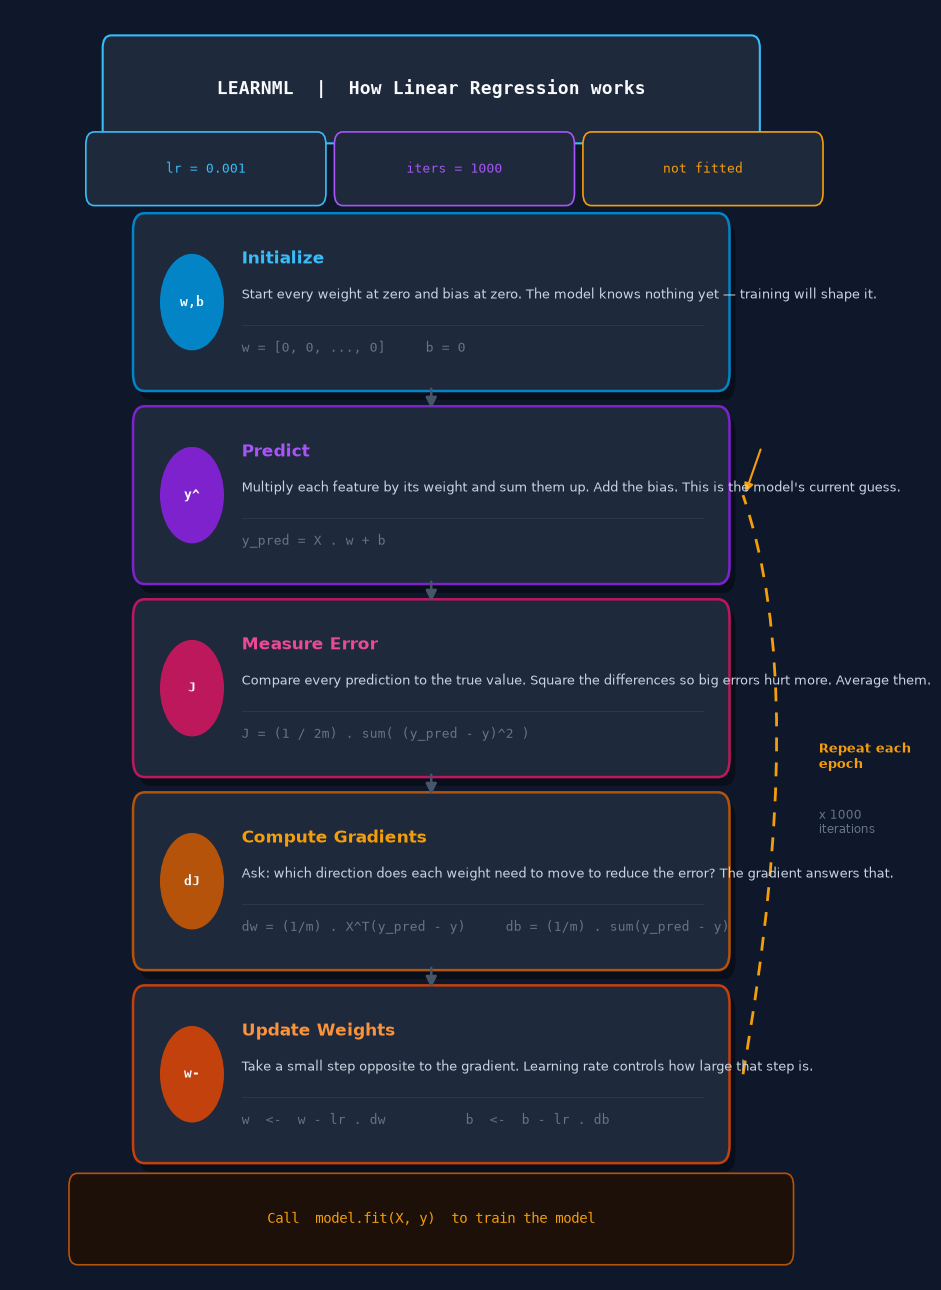

In [108]:
#this function tells the user about the LinearRegression class, including its purpose, usage, and examples. It is a helpful resource for users who want to learn more about linear regression and how to use it in their machine learning projects.
learn_about_LinearRegression()



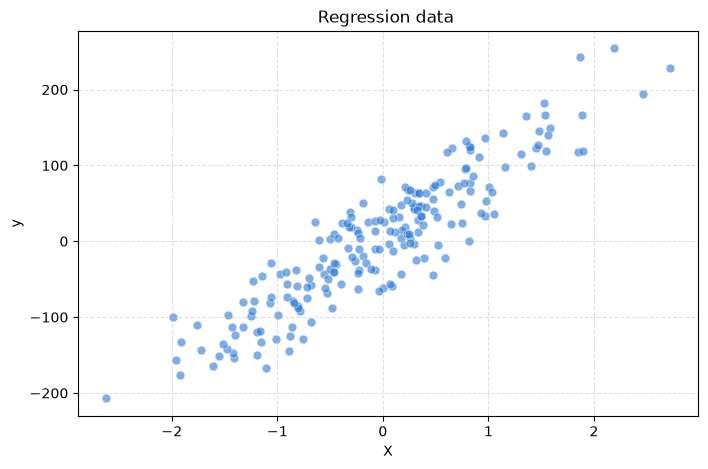

In [109]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=1, noise=35, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="#2a78d6", alpha=0.6, s=40, edgecolors="white", linewidth=0.5)
plt.title("Regression data ")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [110]:
print("X :")
print(X)



X :
[[ 1.85227818]
 [ 0.47359243]
 [-1.23086432]
 [ 0.62566735]
 [-0.07201012]
 [ 0.81252582]
 [-0.18565898]
 [-0.81581028]
 [ 0.06023021]
 [ 0.65655361]
 [ 2.46324211]
 [ 1.0035329 ]
 [-0.26465683]
 [-0.23458713]
 [-0.56228753]
 [ 0.29698467]
 [ 0.08704707]
 [ 1.45353408]
 [-0.97468167]
 [-1.4123037 ]
 [-0.50347565]
 [-0.07710171]
 [ 0.38531738]
 [-1.40185106]
 [-0.07282891]
 [ 0.34115197]
 [ 0.8219025 ]
 [-0.44651495]
 [-0.46947439]
 [ 1.86577451]
 [-1.42474819]
 [-0.60170661]
 [ 0.82254491]
 [-0.46341769]
 [ 0.96337613]
 [ 1.52302986]
 [-0.5297602 ]
 [-1.32045661]
 [-0.99053633]
 [ 0.15372511]
 [-0.01349722]
 [ 1.03099952]
 [ 0.75193303]
 [ 1.47789404]
 [ 0.17457781]
 [-1.24573878]
 [ 0.2088636 ]
 [-0.82068232]
 [ 0.17136828]
 [-0.90802408]
 [ 0.52194157]
 [-1.60748323]
 [ 0.19686124]
 [ 0.00511346]
 [-0.30921238]
 [ 1.14282281]
 [-0.56629773]
 [ 0.97554513]
 [-1.41537074]
 [-0.78325329]
 [ 0.29612028]
 [-1.23695071]
 [ 0.73846658]
 [ 0.01300189]
 [ 0.54256004]
 [-0.68002472]
 [ 0.2

In [111]:
print('y :')
print(y)

y :
[ 1.18033387e+02  7.20906803e+01 -5.30415908e+01  6.52360816e+01
 -1.08123993e+01  1.25296195e+02 -1.99683663e+01 -5.88903215e+01
 -4.20197975e+00  1.22703091e+02  1.94659916e+02  7.17490071e+01
 -2.57966669e+01 -6.33019970e+01 -4.31672614e+01 -3.48815647e+00
 -5.87709190e+01  1.22898685e+02 -4.35015409e+01 -1.53869236e+02
  3.35222945e+00  1.32324665e+01 -2.21626122e+01 -1.23303234e+02
 -3.79350963e+01  6.39000893e+01  7.65248315e+01 -3.00973937e+01
 -4.03528049e+01  2.43349677e+02 -1.12497910e+02 -3.35569458e+01
  1.19888118e+02  9.64845102e+00  3.36742963e+01  1.81996700e+02
 -6.82580345e+01 -1.12742752e+02 -9.77252277e+01  3.22296402e+01
  8.24320484e+01  6.48811727e+01  2.40894631e+01  1.45042894e+02
  4.78996801e+01 -9.83617191e+01  1.88551441e+01 -3.78336372e+01
 -4.33842410e+01 -7.38917893e+01 -4.80260156e+00 -1.64918241e+02
 -4.72786644e+00 -6.21198655e+01  3.83907376e+01  1.42440499e+02
 -2.15519811e+01  5.29509945e+01 -1.47602913e+02 -9.19684952e+01
  4.52915911e+01 -9.1

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

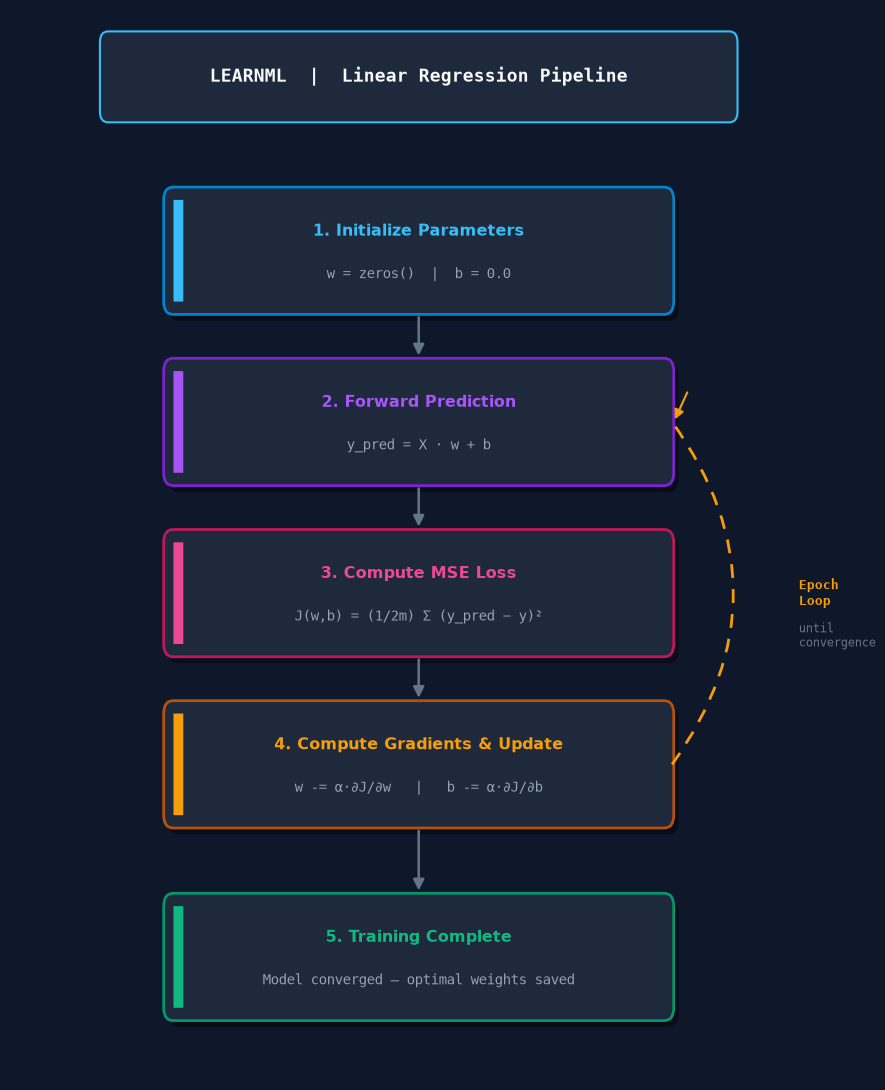

In [113]:
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)


In [114]:
y_pred = linear_regression_model.predict(X_test)
y_pred

array([ 18.7629811 ,  40.80497568,  39.32659589,  11.44676489,
       -45.9920618 , -37.62449518,   4.67826437,  18.54635455,
       106.34448776, -25.6754295 , -22.66690311,  66.3942057 ,
        91.77312113,  -2.04338702, -93.7395905 ,  75.10037589,
        68.62367338, -61.7918246 ,  12.33733684,  26.43995523,
       -39.10828054, -82.98698975, -13.97904591,  -9.76915694,
        30.73731854, -23.37540942,  17.78200737, -62.16198448,
        -4.09399109, -41.1541599 , -55.84153774,  15.4794975 ,
        52.06956275, -75.53742529,  32.8864771 , -90.18193307,
        -9.7683707 , -42.10587186, -14.9681106 ,  40.81252575])

In [115]:
print(regression_report(y_test, y_pred))

Mean Squared Error: 3042.2660898766712
Root Mean Squared Error: 55.15674111001004
Mean Absolute Error: 44.26718887235627
R^2 Score: 0.6792376473107467
None


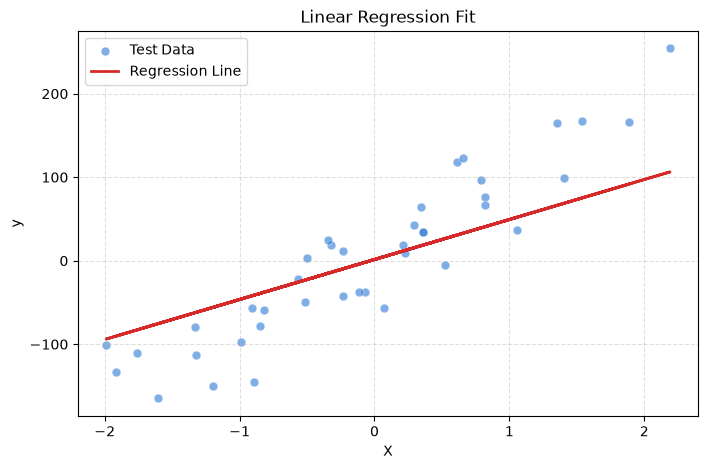

In [116]:
#visulaizing the regression line along with the test data points to see how well the model fits the data.
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color="#2a78d6", alpha=0.6, s=40, edgecolors="white", linewidth=0.5, label="Test Data")
plt.plot(X_test, y_pred, color="#d62a2a", linewidth=2, label="Regression Line")
plt.title("Linear Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

Polynomial Regression is an extension of linear regression that allows for modeling non-linear relationships between the input features and the target variable. It does this by introducing polynomial terms (e.g., x^2, x^3) into the regression equation, enabling the model to fit more complex curves to the data.

Key Concepts:
1. Model Representation: The polynomial regression model can be represented as: y = w0 + w1*x + w2*x^2 + ... + wn*x^n, where y is the predicted output, x is the input feature, and w0, w1, ..., wn are the weights (coefficients).
2. Degree of Polynomial: The degree of the polynomial determines the flexibility of the model. A higher degree allows for more complex curves but may lead to overfitting.
3. Feature Transformation: Polynomial regression involves transforming the original features into polynomial features before fitting the model.

Applications:
- Modeling growth rates in biology or economics.
- Predicting trends in stock prices or market data.
- Fitting curv

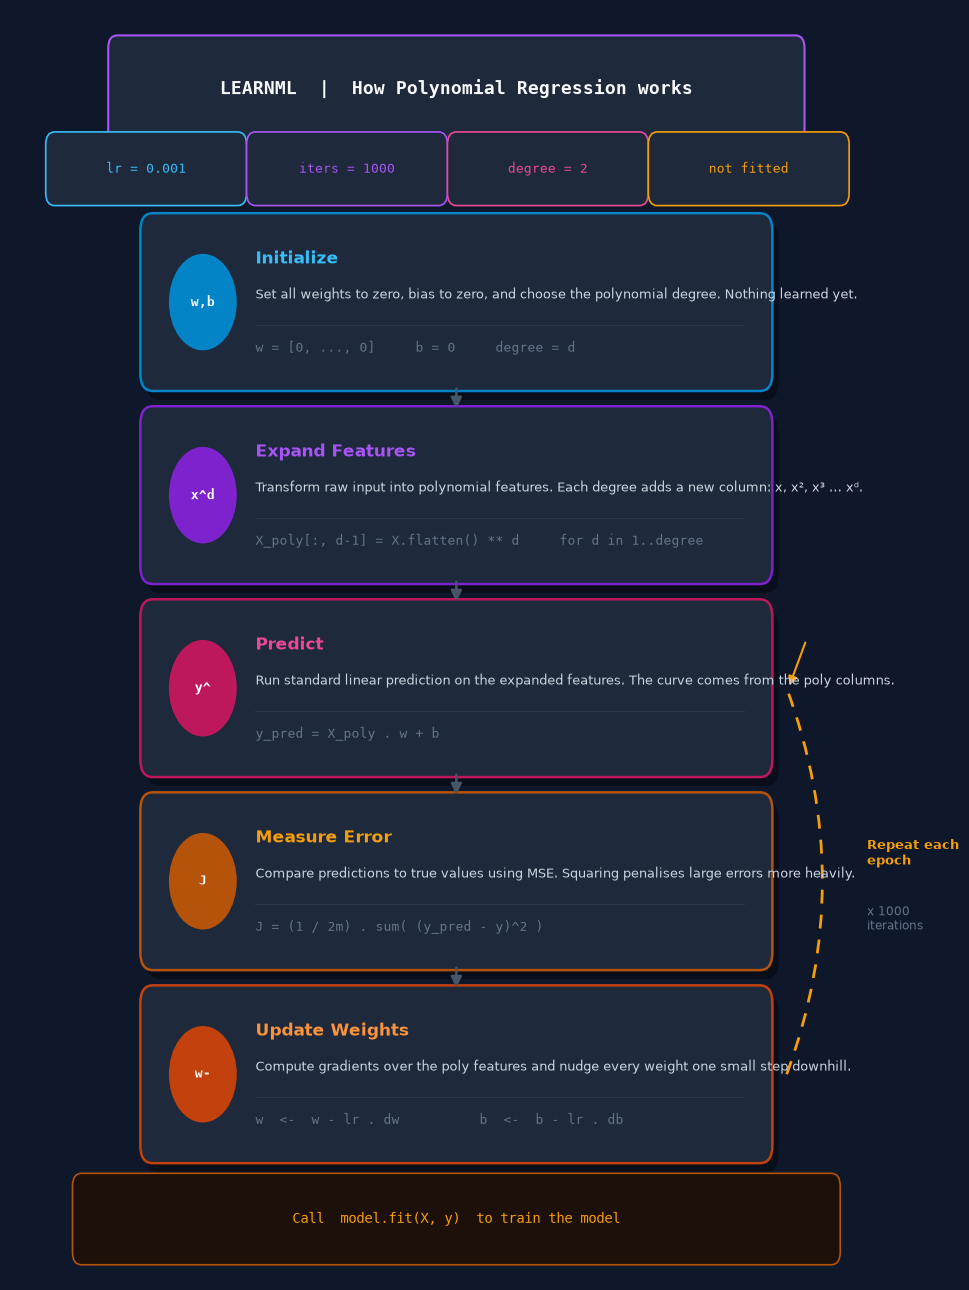

In [117]:
#lets learn about polynomial regression and how it can be used to model more complex relationships between the input features and the target variable. The learn_about_PolynomialRegression function provides information on the PolynomialRegression class, including its purpose, usage, and examples.
learn_about_PolynomialRegression()

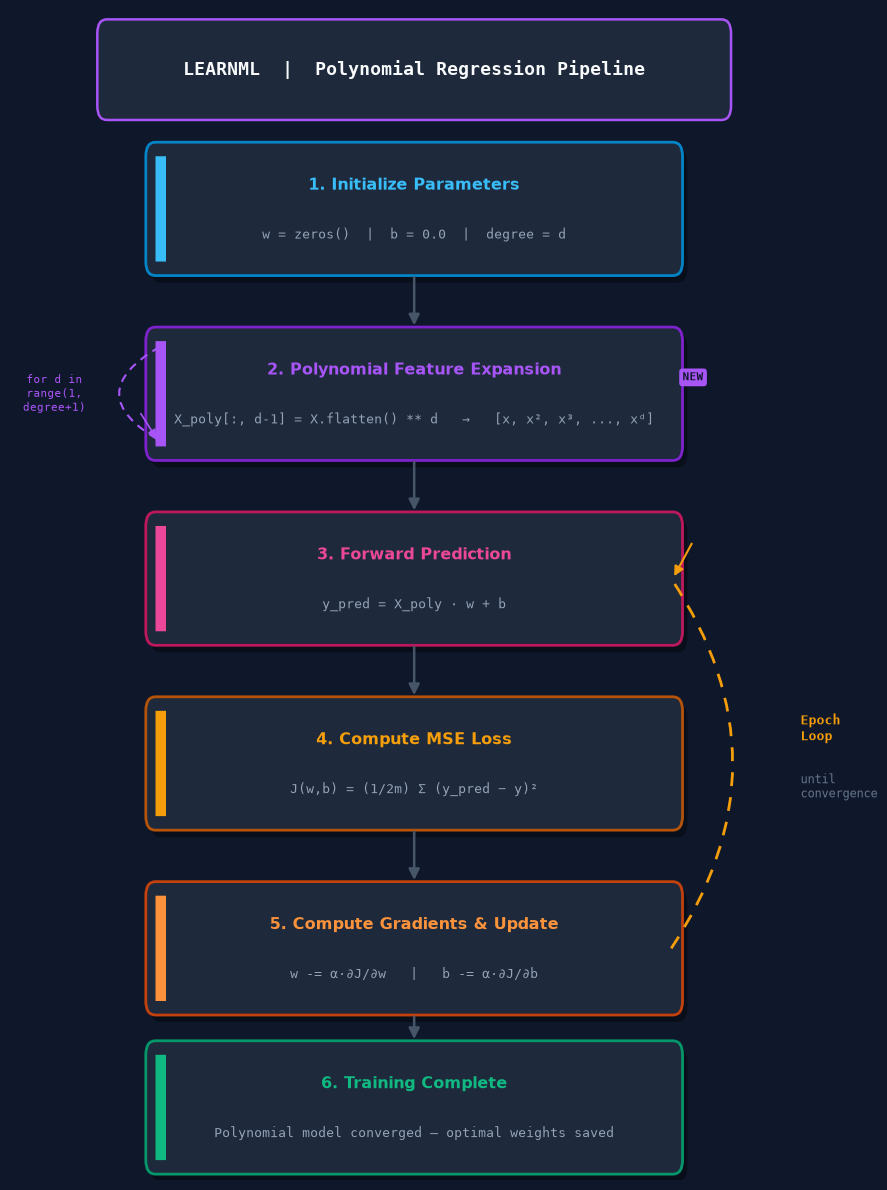

In [118]:
polynomial_regression_model = PolynomialRegression(degree=3)
polynomial_regression_model.fit(X_train, y_train)

In [119]:
y_poly_pred = polynomial_regression_model.predict(X_test)
y_poly_pred


array([ 1.16770211e+01,  2.95199707e+01,  2.79859291e+01,  7.35306891e+00,
       -4.12110356e+01, -2.94891537e+01,  3.61106408e+00,  1.15420322e+01,
        1.96661063e+02, -1.66783575e+01, -1.40435157e+01,  6.80799533e+01,
        1.37635290e+02, -1.06597555e-01, -1.75349031e+02,  8.77746912e+01,
        7.27527354e+01, -7.13300269e+01,  7.85816135e+00,  1.68541612e+01,
       -3.13844903e+01, -1.32793058e+02, -7.45371991e+00, -4.69180487e+00,
        2.01683522e+01, -1.46456728e+01,  1.10697520e+01, -7.21800796e+01,
       -1.27769709e+00, -3.41228096e+01, -5.86214681e+01,  9.68184358e+00,
        4.34276936e+01, -1.08043863e+02,  2.19635019e+01, -1.60325953e+02,
       -4.69130975e+00, -3.54476851e+01, -8.13825900e+00,  2.95279619e+01])

In [120]:
print(regression_report(y_test, y_poly_pred))

Mean Squared Error: 2612.519681554005
Root Mean Squared Error: 51.112813281544234
Mean Absolute Error: 42.50599913493686
R^2 Score: 0.7245481050159512
None


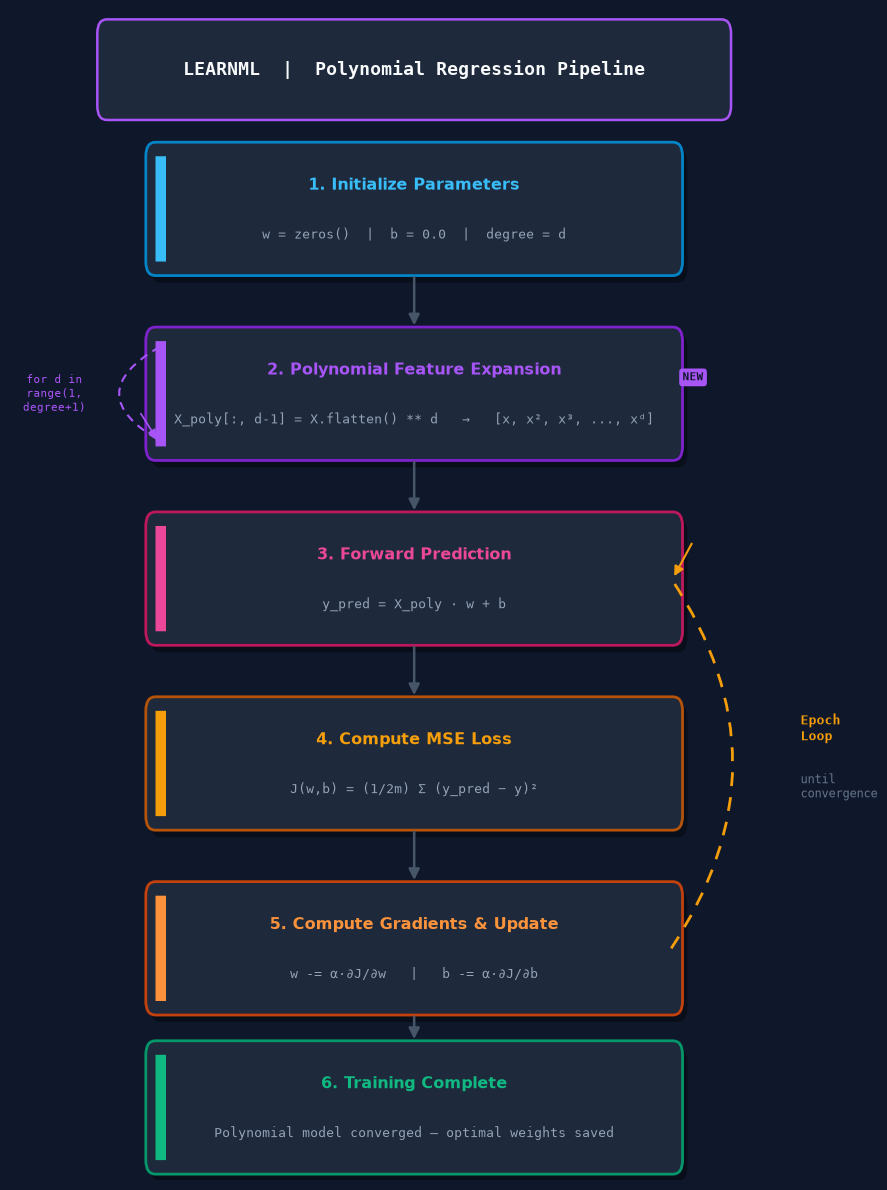

Degree 2 Polynomial Regression Report:
Mean Squared Error: 3017.426486052863
Root Mean Squared Error: 54.9311067251777
Mean Absolute Error: 44.42812191487598
R^2 Score: 0.6818566193293043
None


In [121]:
#try degree 2 and degree 4 to see how the model performs with different polynomial degrees. You can also visualize the polynomial regression fit along with the test data points to see how well the model captures the underlying relationship between the input features and the target variable.
polynomial_regression_model_degree_2 = PolynomialRegression(degree=2)
polynomial_regression_model_degree_2.fit(X_train, y_train)
y_poly_pred_degree_2 = polynomial_regression_model_degree_2.predict(X_test)
print("Degree 2 Polynomial Regression Report:")
print(regression_report(y_test, y_poly_pred_degree_2))

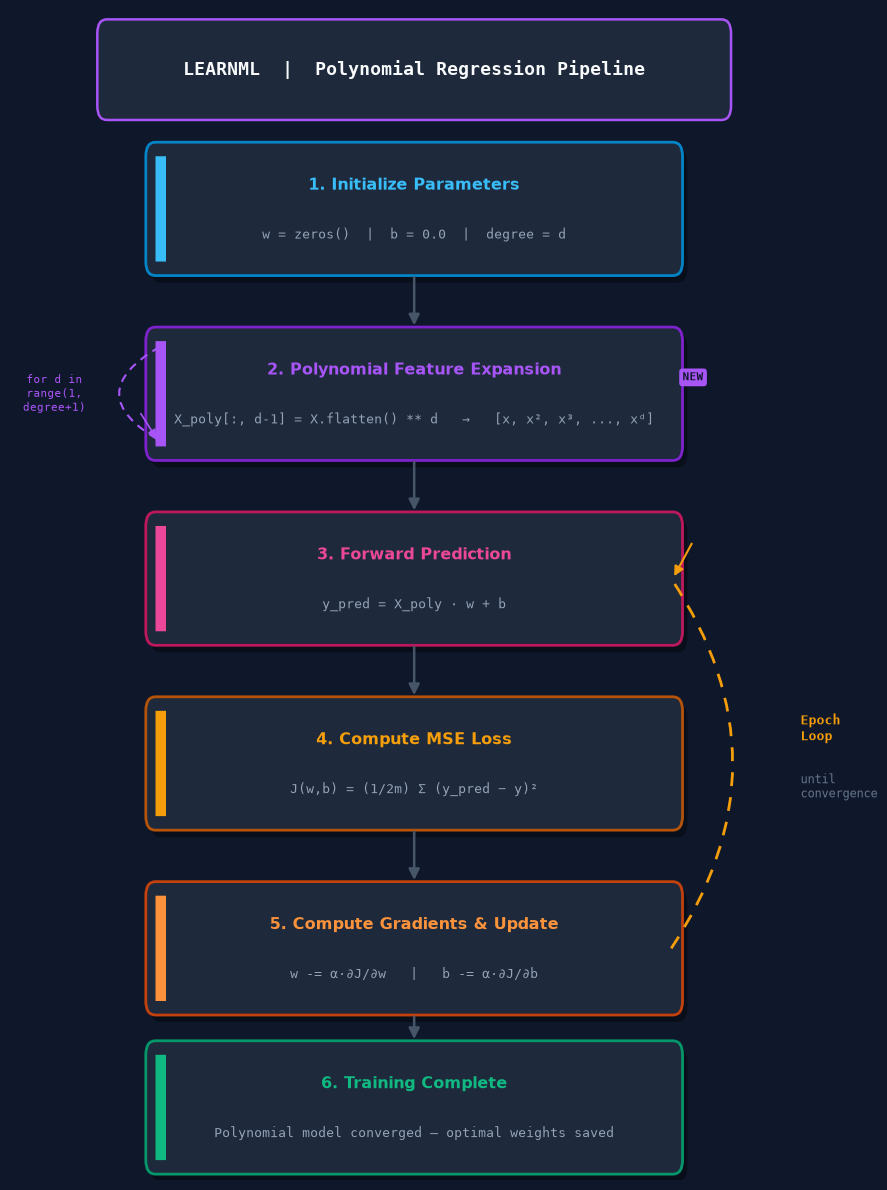

Degree 4 Polynomial Regression Report:
Mean Squared Error: 2615.9038227779756
Root Mean Squared Error: 51.14590719478906
Mean Absolute Error: 42.61517114704643
R^2 Score: 0.7241912969430329
None


In [122]:
#degree 4 polynomial regression
polynomial_regression_model_degree_4 = PolynomialRegression(degree=4)
polynomial_regression_model_degree_4.fit(X_train, y_train)
y_poly_pred_degree_4 = polynomial_regression_model_degree_4.predict(X_test) 
print("Degree 4 Polynomial Regression Report:")
print(regression_report(y_test, y_poly_pred_degree_4))

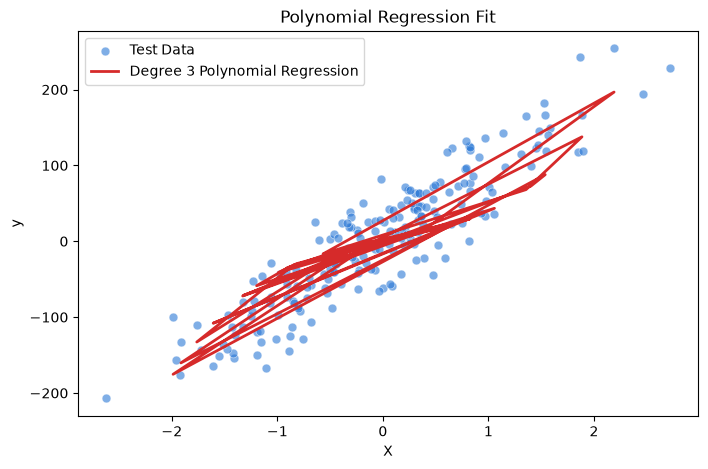

In [132]:
#visulaizing the polynomial regression fit along with the test data points to see how well the model captures the underlying relationship between the input features and the target variable.
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color="#2a78d6", alpha=0.6, s=40, edgecolors="white", linewidth=0.5, label="Test Data")
plt.plot(X_test, y_poly_pred, color="#d62a2a", linewidth=2, label="Degree 3 Polynomial Regression")
plt.title("Polynomial Regression Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()


NEW DATA 

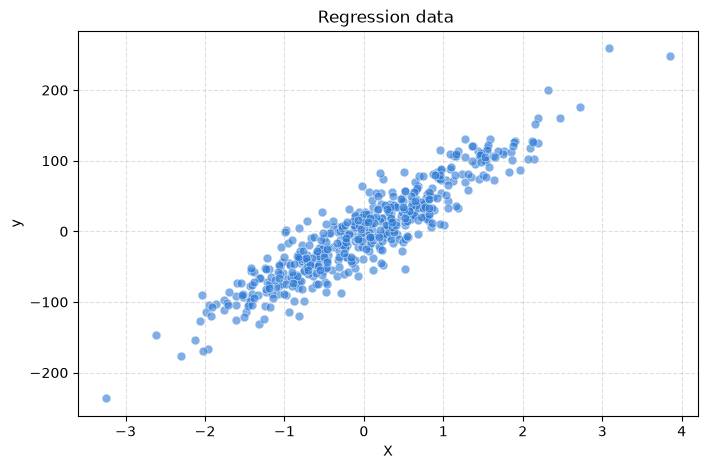

In [124]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X_new, y_new = make_regression(n_samples=500, n_features=1, noise=25, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X_new, y_new, color="#2a78d6", alpha=0.6, s=40, edgecolors="white", linewidth=0.5)
plt.title("Regression data ")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

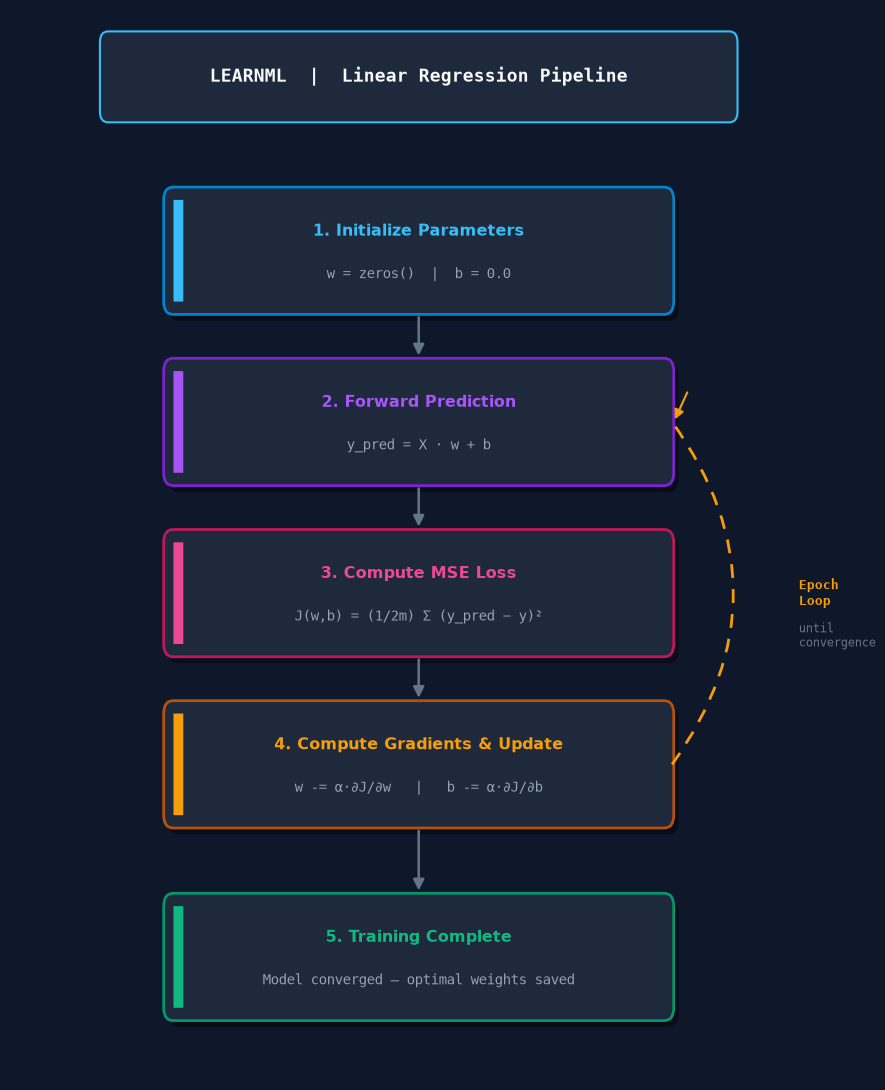

In [125]:
#linear regression on the new dataset
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)
new_linear_regression_model = LinearRegression()
new_linear_regression_model.fit(X_train_new, y_train_new)

In [126]:
y_pred_new = new_linear_regression_model.predict(X_test_new)
y_pred_new

array([-1.01095193e+01, -1.94736904e+01, -6.81225237e+01,  2.66863906e+01,
       -8.86712458e+00,  1.33736401e+01,  8.47092157e+01,  1.61975599e+00,
        8.42768928e+01,  3.04520809e+01, -2.01232614e+01, -9.75348138e-01,
        1.97304005e+01,  2.26035330e+01, -2.85847712e+01, -2.24382366e+01,
        3.23250320e+01, -7.89966304e+01, -5.25543182e+01, -1.88322660e+01,
       -3.08712996e+01,  7.82019365e+00, -9.18788231e+00,  9.34565217e+00,
        4.15137509e+01, -8.94600287e+00,  5.83990786e+01,  2.03366432e+01,
       -2.58038230e+01,  4.16969089e+01, -3.91750378e-02, -3.22695607e+01,
       -2.76974335e+01,  1.19345560e+01, -3.16583471e+01, -3.99657154e+01,
        8.95288878e+00,  3.40626380e+01, -9.51916248e+00, -3.57943303e+01,
        1.97676771e+01,  6.66090107e+01,  3.70676701e+00, -4.58484173e+01,
        6.97120462e+01,  4.06102302e+01, -1.89414774e+01, -7.62706108e+01,
       -1.11403560e+01,  7.07408813e+00,  7.40990479e+01,  1.39083335e+01,
       -1.61396301e+01, -

In [127]:
print(regression_report(y_test_new, y_pred_new))

Mean Squared Error: 1045.343563985414
Root Mean Squared Error: 32.33177328859978
Mean Absolute Error: 26.032492926853774
R^2 Score: 0.7389970893534347
None


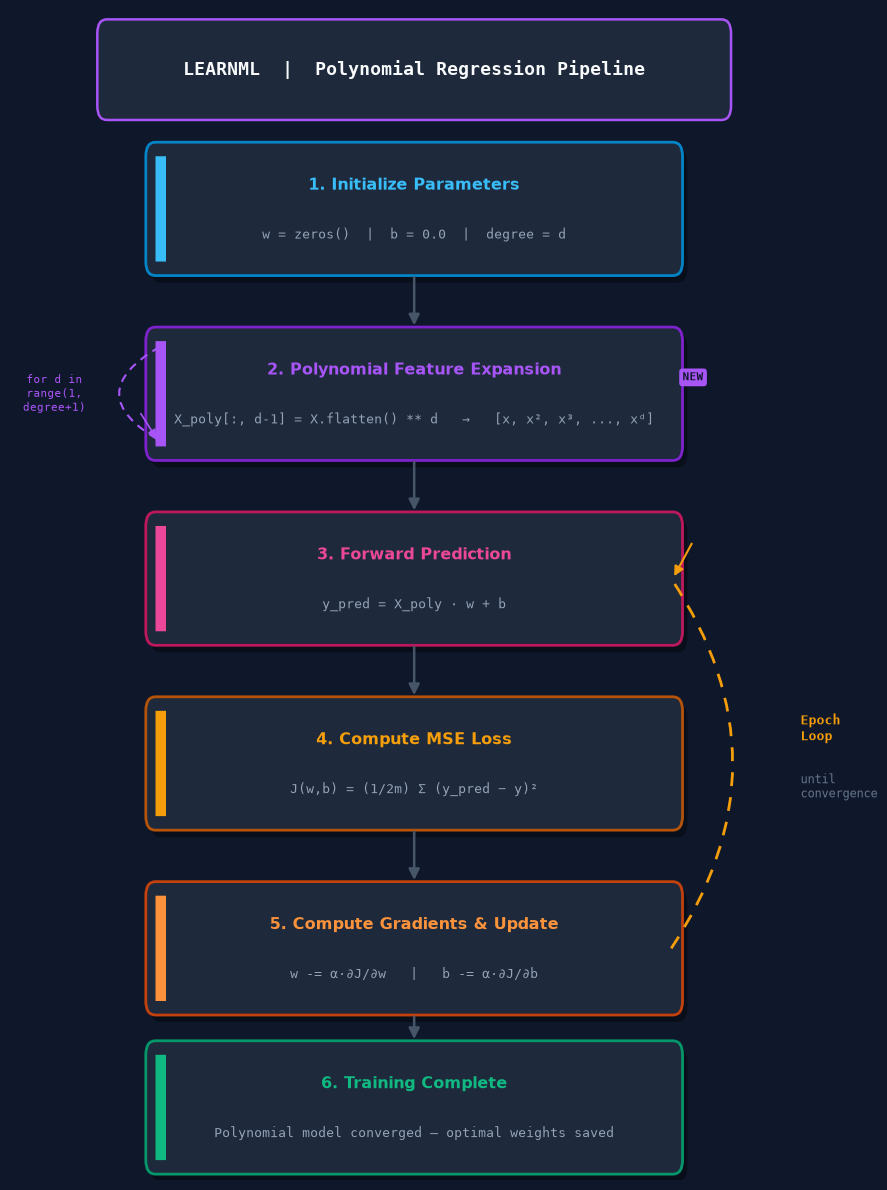

In [128]:
new_polynomial_regression_model = PolynomialRegression(degree=3)
new_polynomial_regression_model.fit(X_train_new, y_train_new)

In [129]:
poly_pred_new = new_polynomial_regression_model.predict(X_test_new)
print(regression_report(y_test_new, poly_pred_new))

Mean Squared Error: 1070.0609727959918
Root Mean Squared Error: 32.71178645069681
Mean Absolute Error: 26.998601517899164
R^2 Score: 0.7328256105540569
None
